<a href="https://colab.research.google.com/github/KingsleyNahyi/AI-final-project/blob/main/Copy_of_Decision_training_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

# Check if the dataset file already exists to avoid re-downloading
if not os.path.exists('KaggleV2-May-2016.csv'):
    # To use Kaggle API, you need to upload your kaggle.json file.
    # You might need to install the kaggle library if it's not already available:
    # !pip install -q kaggle

    print("Downloading dataset from Kaggle...")
    # The dataset is 'Medical Appointment No Shows' by joniarroba
    !kaggle datasets download -d joniarroba/noshowappointments

    print("Unzipping dataset...")
    # The downloaded file is named 'noshowappointments.zip'
    !unzip -o noshowappointments.zip

#loading the data and getting description of it
df = pd.read_csv('KaggleV2-May-2016.csv')
df.info()
df.describe()
df.isnull().sum()

Dataset URL: https://www.kaggle.com/datasets/joniarroba/noshowappointments
License(s): CC-BY-NC-SA-4.0
100% 2.40M/2.40M [00:01<00:00, 1.87MB/s]

Unzipping dataset...
Archive:  noshowappointments.zip
  inflating: KaggleV2-May-2016.csv   
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [ ]:
#renmaing the columns python standard.
df = df.rename(columns = {
'PatientId' : 'patient_id',
'AppointmentID' : 'appointment_id',
'ScheduledDay': 'scheduled_day',
'AppointmentDay': 'appointment_day',
'Hipertension': 'hypertension',
'Handcap': 'handicap',
'SMS_received':'sms_received',
'No-show': 'no_show',
'Age': 'age',
'Gender': 'gender',
'Neighbourhood': 'neighbourhood'
})

#dropping duplicates
df = df.drop_duplicates()

#removing negative ages.
df = df[df['age'] >= 0]

#converting dates to datime
df['scheduled_day'] = pd.to_datetime(df['scheduled_day'])
df['appointment_day'] = pd.to_datetime(df['appointment_day'])

#subtracting the scheduled day from the appointment day to get the number of days until the appointment.
df['days_until_appointment'] = (df['appointment_day'].dt.normalize()
                                - df['scheduled_day'].dt.normalize()).dt.days
df = df[df['days_until_appointment'] >= 0]

#MAPPING THE NO SHOW COLUMNS TO 1 AND 0 F0R YES AND NO RESPECTIVELY
df['no_show'] = df['no_show'].map({'Yes':1, 'No':0})
df['gender'] = df['gender'].map({'F':0, 'M':1})

df['appt_weekday'] = df['appointment_day'].dt.day_name()
df = pd.get_dummies(df, columns=['appt_weekday'], drop_first=True)

#dropping features or columns that are not important.
df = df.drop(columns=['patient_id', 'appointment_id', 'scheduled_day', 'appointment_day'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71959 entries, 5 to 110526
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   gender                  71959 non-null  int64 
 1   age                     71959 non-null  int64 
 2   neighbourhood           71959 non-null  object
 3   Scholarship             71959 non-null  int64 
 4   hypertension            71959 non-null  int64 
 5   Diabetes                71959 non-null  int64 
 6   Alcoholism              71959 non-null  int64 
 7   handicap                71959 non-null  int64 
 8   sms_received            71959 non-null  int64 
 9   no_show                 71959 non-null  int64 
 10  days_until_appointment  71959 non-null  int64 
 11  appt_weekday_Monday     71959 non-null  bool  
 12  appt_weekday_Saturday   71959 non-null  bool  
 13  appt_weekday_Thursday   71959 non-null  bool  
 14  appt_weekday_Tuesday    71959 non-null  bool  
 15  appt_w

In [ ]:
# Evaluating the data using decision tree
target_col = 'no_show'

X = df.drop(target_col, axis=1)
y = df[target_col]

print(X.shape)
print(y.shape)

(71959, 15)
(71959,)


In [ ]:
# Dividing the data into training and testing data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57567 entries, 97376 to 36307
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   gender                  57567 non-null  int64 
 1   age                     57567 non-null  int64 
 2   neighbourhood           57567 non-null  object
 3   Scholarship             57567 non-null  int64 
 4   hypertension            57567 non-null  int64 
 5   Diabetes                57567 non-null  int64 
 6   Alcoholism              57567 non-null  int64 
 7   handicap                57567 non-null  int64 
 8   sms_received            57567 non-null  int64 
 9   days_until_appointment  57567 non-null  int64 
 10  appt_weekday_Monday     57567 non-null  bool  
 11  appt_weekday_Saturday   57567 non-null  bool  
 12  appt_weekday_Thursday   57567 non-null  bool  
 13  appt_weekday_Tuesday    57567 non-null  bool  
 14  appt_weekday_Wednesday  57567 non-null  bool  
dtypes: 

In [ ]:
# Encoding categorical variables.
import pandas as pd

x_train = pd.get_dummies(
    x_train,
    columns=['neighbourhood'],
    drop_first=True
)

x_test = pd.get_dummies(
    x_test,
    columns=['neighbourhood'],
    drop_first=True
)

x_test = x_test.reindex(
    columns=x_train.columns,
    fill_value=0
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    min_samples_leaf=20
)

rf_model.fit(x_train, y_train)

y_pred = rf_model.predict(x_test)

In [ ]:
# Evaluating the model
from sklearn.metrics import (
  roc_auc_score,
  average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test,y_pred))

print("Precision:", precision_score(y_test,y_pred))

print("Recall:", recall_score(y_test,y_pred))

print("F1 Score:", f1_score(y_test,y_pred))

print(classification_report(y_test,y_pred))


proba = rf_model.predict_proba(x_test)[:, 1]
print("ROC-AUC  :", roc_auc_score(y_test, proba))
print("PR-AUC   :", average_precision_score(y_test, proba))
print("Baseline :", 1 - y_test.mean())

Accuracy: 0.6903835464146748
Precision: 0.41737089201877936
Recall: 0.21661793372319688
F1 Score: 0.2852101379531601
              precision    recall  f1-score   support

           0       0.74      0.88      0.80     10288
           1       0.42      0.22      0.29      4104

    accuracy                           0.69     14392
   macro avg       0.58      0.55      0.54     14392
weighted avg       0.65      0.69      0.65     14392



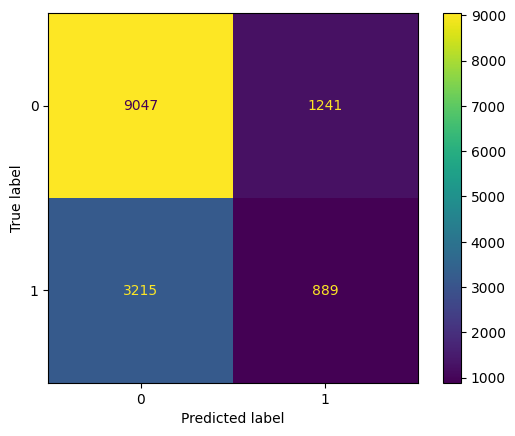

In [ ]:
# Ploting the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [ ]:
# Feature importance.
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
1,age,0.331952
8,days_until_appointment,0.226368
0,gender,0.036001
7,sms_received,0.022042
12,appt_weekday_Tuesday,0.020199
13,appt_weekday_Wednesday,0.017367
11,appt_weekday_Thursday,0.015881
9,appt_weekday_Monday,0.014646
3,hypertension,0.012170
2,Scholarship,0.009877
